In [1]:
import pandas as pd

In [4]:
df  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results.csv')

In [5]:
new_model = df.sort_values(by=['similarity_score'], ascending=False)

In [6]:
df2  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/basemodel_unseen_results.csv')
base_model = df2.sort_values(by=['similarity_score'], ascending=False)

In [7]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('Base Model Similarity:', base_model['similarity_score'].mean())

Base Model Similarity: 0.5847


In [8]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('New Model Similarity:', new_model['similarity_score'].mean())

New Model Similarity: 0.7088999999999999


In [9]:
base_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
0,1,Get unique values of wind_fcst. \nColumns: sta...,df['wind_fcst'].unique(),"data = {'start_time': ['2023-04-01 09:00:00', ...",0.11,False,False,NaN
5,6,Compute the sum of wind_fcst grouped by zone. ...,df.groupby('zone')['wind_fcst'].sum(),"data = {'predicted': [50, 60, 70],'fcst_time':...",0.14,False,False,NaN
21,22,Compute the mean of wind_fcst grouped by metho...,df.groupby('method')['wind_fcst'].mean(),data = {'fcst_time': [pd.Timestamp('2023-04-01...,0.15,False,False,NaN
50,51,Filter rows where day_ahead_forecast is greate...,df[df['day_ahead_forecast'] > 36],df = pd.DataFrame({'start_time': [pd.Timestamp...,0.16,False,False,NaN
91,92,Compute count of rows grouped by method. \nCol...,df.groupby('method').size(),data = {'start_time': [pd.Timestamp('2023-04-0...,0.16,False,False,NaN
...,...,...,...,...,...,...,...,...
28,29,Count unique values of price_rt. \nColumns: pr...,df['price_rt'].nunique(),df['price_rt'].nunique(),1.00,True,True,NaN
98,99,Get unique values of total. \nColumns: start_t...,df['total'].unique(),df['total'].unique(),1.00,True,True,NaN
81,82,Count unique values of day_ahead_forecast. \nC...,df['day_ahead_forecast'].nunique(),df['day_ahead_forecast'].nunique(),1.00,True,True,NaN
87,88,Count unique values of price_rt_scaled. \nColu...,df['price_rt_scaled'].nunique(),df['price_rt_scaled'].nunique(),1.00,True,True,NaN


In [10]:
new_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
30,31,Compute the mean and std of wind_fcst grouped ...,"df.groupby('zone')['wind_fcst'].agg(['mean','s...","""""",0.0,False,False,NaN
24,25,Compute the sum of power grouped by region. \n...,df.groupby('region')['power'].sum(),"""""",0.0,False,False,NaN
40,41,Compute the mean of load_fcst grouped by zone....,df.groupby('zone')['load_fcst'].mean(),"""""",0.0,False,False,NaN
48,49,Compute the sum of predicted grouped by zone. ...,df.groupby('zone')['predicted'].sum(),"""""",0.0,False,False,NaN
77,78,Compute the mean of predicted_err grouped by r...,df.groupby('region')['predicted_err'].mean(),"""""",0.0,False,False,NaN
...,...,...,...,...,...,...,...,...
14,15,Get unique values of solar_fcst_adj. \nColumns...,df['solar_fcst_adj'].unique(),df['solar_fcst_adj'].unique(),1.0,True,True,NaN
95,96,Compute the mean of price_rt grouped by region...,df.groupby('region')['price_rt'].mean(),df.groupby('region')['price_rt'].mean(),1.0,True,True,NaN
5,6,Compute the sum of wind_fcst grouped by zone. ...,df.groupby('zone')['wind_fcst'].sum(),df.groupby('zone')['wind_fcst'].sum(),1.0,True,True,NaN
57,58,Compute the sum of price_da grouped by region....,df.groupby('region')['price_da'].sum(),df.groupby('region')['price_da'].sum(),1.0,True,True,NaN


In [11]:
num = 31

In [12]:
print(new_model[new_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(new_model[new_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(new_model[new_model['test_case_id'] == num]['generated_output'].values[0])

Compute the mean and std of wind_fcst grouped by zone. 
Columns: start_time, power, wind_fcst, day_ahead_forecast, load_fcst, zone
------------------
df.groupby('zone')['wind_fcst'].agg(['mean','std'])
-----
""


In [13]:
print(base_model[base_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(base_model[base_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(base_model[base_model['test_case_id'] == num]['generated_output'].values[0])

Compute the mean and std of wind_fcst grouped by zone. 
Columns: start_time, power, wind_fcst, day_ahead_forecast, load_fcst, zone
------------------
df.groupby('zone')['wind_fcst'].agg(['mean','std'])
-----
(df.groupby('zone').agg({'wind_fcst': 'mean','wind_fcst': 'std'}))if not result.empty:result.columns = [f'{col}_mean',f'{col}_


In [14]:
new_model[new_model['similarity_score'] > .85]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
0,1,Get unique values of wind_fcst. \nColumns: sta...,df['wind_fcst'].unique(),df['wind_fcst'].unique(),1.00,True,True,NaN
20,21,Compute the sum of wind_fcst grouped by region...,df.groupby('region')['wind_fcst'].sum(),df.groupby('region')['wind_fcst'].sum(),1.00,True,True,NaN
84,85,Compute the sum of total_delta grouped by meth...,df.groupby('method')['total_delta'].sum(),df.groupby('method')['total_delta'].sum(),1.00,True,True,NaN
49,50,Count unique values of load_fcst_raw. \nColumn...,df['load_fcst_raw'].nunique(),df['load_fcst_raw'].nunique(),1.00,True,True,NaN
79,80,Compute the mean of power grouped by region. \...,df.groupby('region')['power'].mean(),df.groupby('region')['power'].mean(),1.00,True,True,NaN
26,27,Compute the mean of total_raw grouped by metho...,df.groupby('method')['total_raw'].mean(),df.groupby('method')['total_raw'].mean(),1.00,True,True,NaN
29,30,Compute the mean of day_ahead_forecast grouped...,df.groupby('region')['day_ahead_forecast'].mean(),df.groupby('region')['day_ahead_forecast'].mean(),1.00,True,True,NaN
68,69,Count unique values of solar_fcst_scaled. \nCo...,df['solar_fcst_scaled'].nunique(),df['solar_fcst_scaled'].nunique(),1.00,True,True,NaN
63,64,Compute the sum of price_rt_v2 grouped by regi...,df.groupby('region')['price_rt_v2'].sum(),df.groupby('region')['price_rt_v2'].sum(),1.00,True,True,NaN
37,38,Get unique values of total. \nColumns: fcst_ti...,df['total'].unique(),df['total'].unique(),1.00,True,True,NaN


In [15]:
print('New Model:', new_model["is_correct"].mean().round(4))
print('Base Model:', base_model["is_correct"].mean().round(4))

New Model: 0.55
Base Model: 0.28


In [16]:
print('New Model:', new_model["method_correct"].mean().round(4))
print('Base Model:', base_model["method_correct"].mean().round(4))

New Model: 0.65
Base Model: 0.47


In [17]:
print('New Model:', new_model.loc[~new_model["is_correct"], "similarity_score"].mean())
print('Base Model:', base_model.loc[~base_model["is_correct"], "similarity_score"].mean())

New Model: 0.3882222222222222
Base Model: 0.4325


In [18]:
print('New Model:', new_model.loc[~new_model["method_correct"], "similarity_score"].mean())
print('Base Model:', base_model.loc[~base_model["method_correct"], "similarity_score"].mean())

New Model: 0.2711428571428571
Base Model: 0.29358490566037737


In [19]:
near_miss_rate = (
    (new_model["similarity_score"] >= 0.8) &
    (new_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.04)

In [20]:
near_miss_rate = (
    (base_model["similarity_score"] >= 0.8) &
    (base_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.08)

In [21]:
print('New Model:', (new_model["similarity_score"] < 0.7).mean())
print('Base Model:', (base_model["similarity_score"] < 0.7).mean())

New Model: 0.35
Base Model: 0.53


In [22]:
new_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Extract,0.000000,0.542500,8
Return,0.000000,0.341429,7
Compute,0.333333,0.490000,36
Filter,0.764706,0.920588,17
Count,0.818182,0.946364,11
Get,1.000000,1.000000,10
Sort,1.000000,0.950909,11


In [23]:
base_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Extract,0.000000,0.283750,8
Filter,0.000000,0.422353,17
Return,0.000000,0.314286,7
Compute,0.055556,0.515556,36
Get,0.600000,0.792000,10
Count,0.909091,0.920000,11
Sort,0.909091,0.929091,11


In [24]:
final_score = (
    0.3 * new_model["is_correct"].mean() +
    0.4 * new_model["method_correct"].mean() +
    0.3 * new_model["similarity_score"].mean()
)

final_score

np.float64(0.63767)

In [25]:
final_score = (
    0.3 * base_model["is_correct"].mean() +
    0.4 * base_model["method_correct"].mean() +
    0.3 * base_model["similarity_score"].mean()
)

final_score

np.float64(0.44741)

In [26]:
cols = ["test_case_id", "is_correct", "similarity_score", "method_correct"]

new2 = new_model[cols].sort_values("test_case_id").reset_index(drop=True)
base2 = base_model[cols].sort_values("test_case_id").reset_index(drop=True)

assert (new2["test_case_id"] == base2["test_case_id"]).all()

In [27]:
# from scipy.stats import ttest_rel

# t_stat, p_value = ttest_rel(
#     new2["similarity_score"],
#     base2["similarity_score"]
# )

# t_stat, p_value

In [28]:

# import numpy as np
# diff = new2["similarity_score"] - base2["similarity_score"]

# boot_means = []
# rng = np.random.default_rng(42)

# for _ in range(10000):
#     sample = rng.choice(diff, size=len(diff), replace=True)
#     boot_means.append(sample.mean())

# ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
# mean_diff = diff.mean()

# mean_diff, ci_low, ci_high

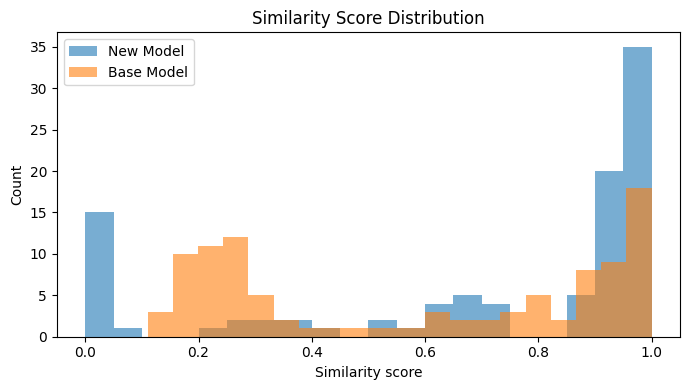

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(new2["similarity_score"], bins=20, alpha=0.6, label="New Model")
plt.hist(base2["similarity_score"], bins=20, alpha=0.6, label="Base Model")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.legend()
plt.title("Similarity Score Distribution")
plt.tight_layout()
plt.show()

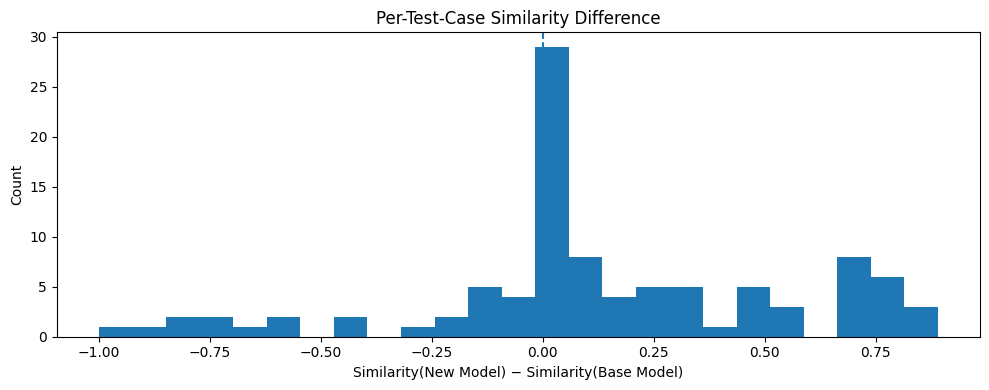

In [30]:
diff = new2["similarity_score"] - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.hist(diff, bins=25)
plt.axvline(0, linestyle="--")
plt.xlabel("Similarity(New Model) − Similarity(Base Model)")
plt.ylabel("Count")
plt.title("Per-Test-Case Similarity Difference")
plt.tight_layout()
plt.show()

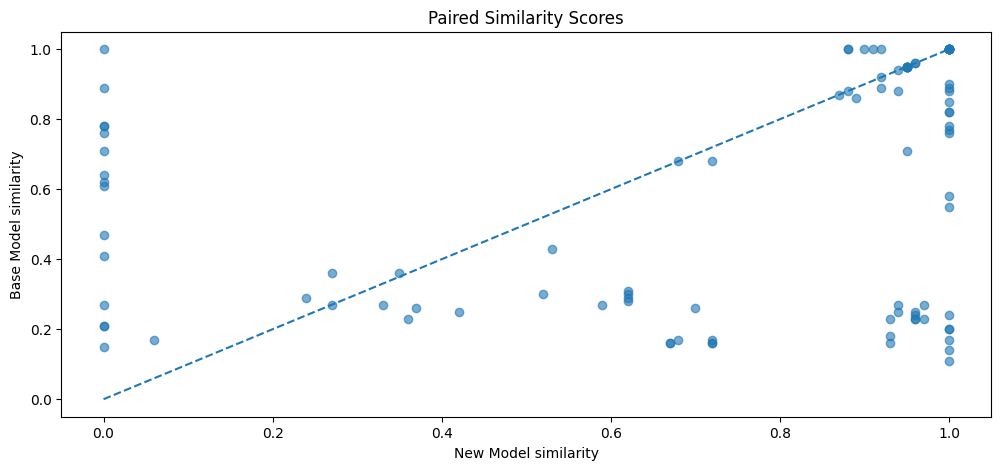

In [31]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= new2["similarity_score"],
    y= base2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("New Model similarity")
plt.ylabel("Base Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

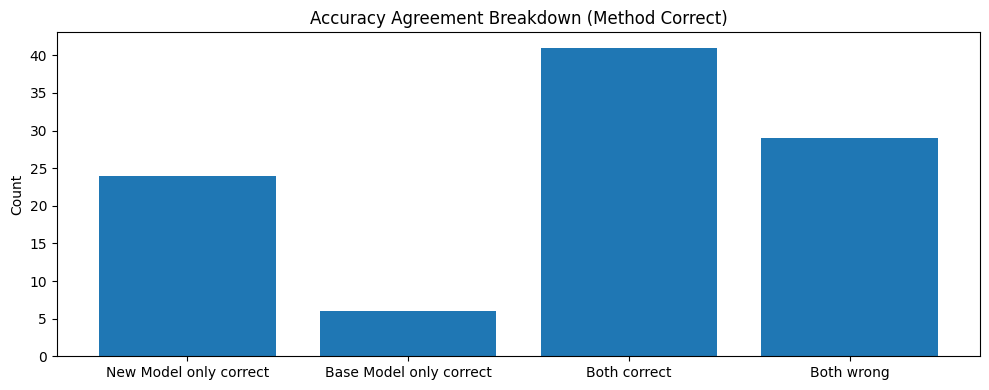

In [32]:
a_only = ((new2.method_correct) & (~base2.method_correct)).sum()
b_only = ((~new2.method_correct) & (base2.method_correct)).sum()
both = ((new2.method_correct) & (base2.method_correct)).sum()
neither = ((~new2.method_correct) & (~base2.method_correct)).sum()

plt.figure(figsize=(10,4))
plt.bar(
    ["New Model only correct", "Base Model only correct", "Both correct", "Both wrong"],
    [a_only, b_only, both, neither]
)
plt.ylabel("Count")
plt.title("Accuracy Agreement Breakdown (Method Correct)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_48777/2770892061.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_new, err_base], labels=["New Model", "Base Model"])


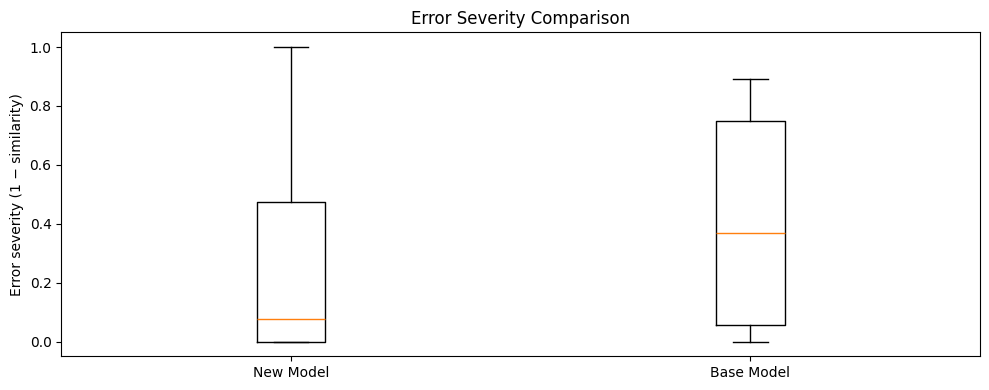

In [33]:
err_new = 1 - new2["similarity_score"]
err_base = 1 - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.boxplot([err_new, err_base], labels=["New Model", "Base Model"])
plt.ylabel("Error severity (1 − similarity)")
plt.title("Error Severity Comparison")
plt.tight_layout()
plt.show()

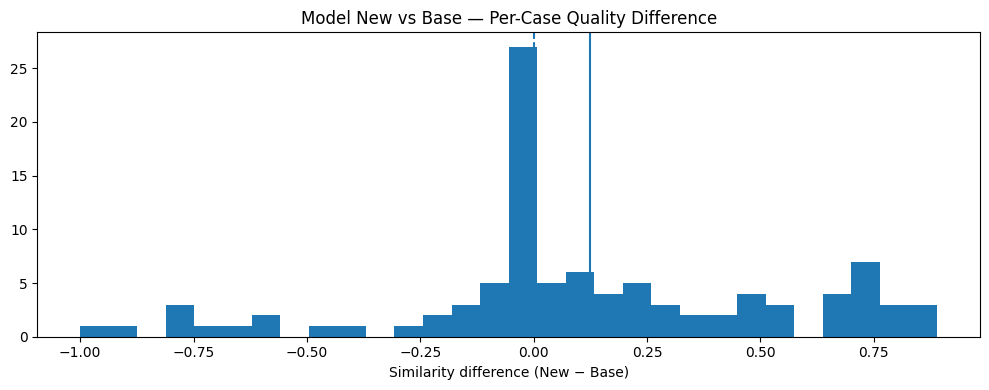

In [34]:
plt.figure(figsize=(10,4))
plt.hist(diff, bins=30)
plt.axvline(0, linestyle="--")
plt.axvline(diff.mean())
plt.title("Model New vs Base — Per-Case Quality Difference")
plt.xlabel("Similarity difference (New − Base)")
plt.tight_layout()
plt.show()

In [35]:
new_model["task_type"] = (
    new_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group)')
    .fillna("other")
)

base_model["task_type"] = (
    base_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group)')
    .fillna("other")
)

In [36]:
task_stats_new = (
    new_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_new

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.542500,1.000000,0.457500,8
compute,0.333333,0.490000,0.666667,0.510000,36
other,0.678571,0.814286,0.321429,0.185714,28
filter,0.764706,0.920588,0.235294,0.079412,17
sort,1.000000,0.950909,0.000000,0.049091,11


In [37]:
task_stats_base = (
    base_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_base

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.283750,1.000000,0.716250,8
filter,0.000000,0.422353,1.000000,0.577647,17
compute,0.055556,0.515556,0.944444,0.484444,36
other,0.571429,0.722857,0.428571,0.277143,28
sort,0.909091,0.929091,0.090909,0.070909,11


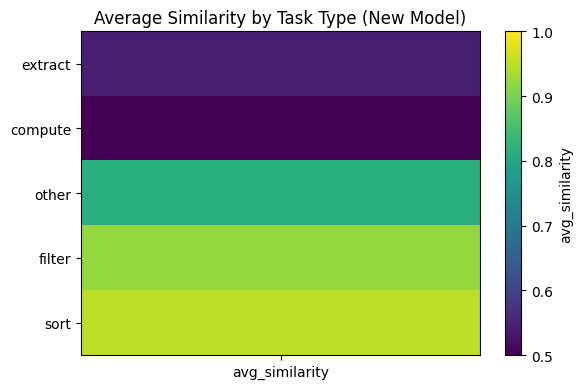

In [38]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_new[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_new)), task_stats_new.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (New Model)")
plt.tight_layout()
plt.show()

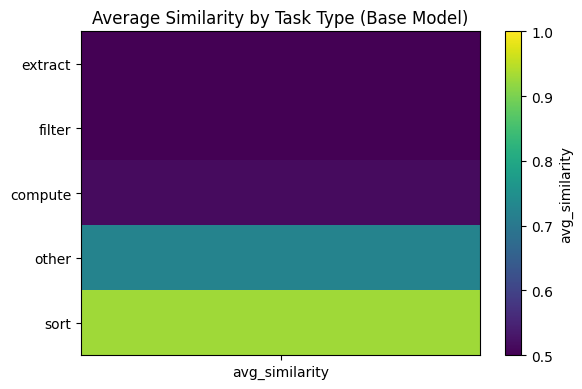

In [39]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_base[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_base)), task_stats_base.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (Base Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_48777/295813842.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  new_model.pivot_table(


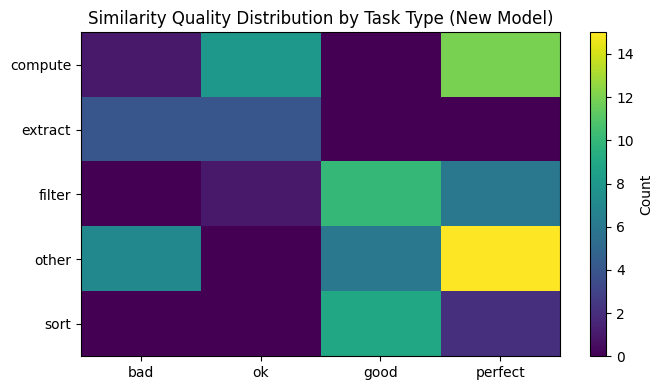

In [40]:
new_model["sim_bin"] = pd.cut(
    new_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    new_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (New Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_48777/2786547845.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  base_model.pivot_table(


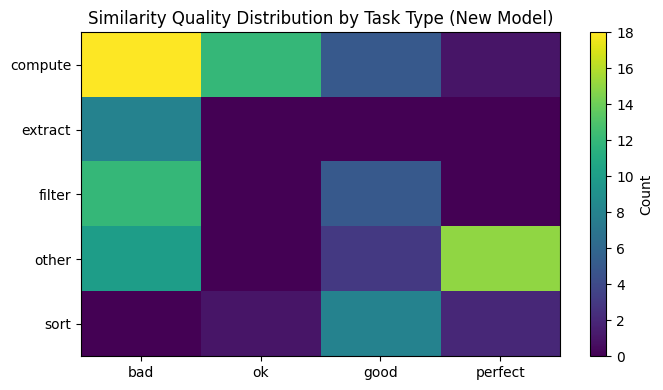

In [41]:
base_model["sim_bin"] = pd.cut(
    base_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    base_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (New Model)")
plt.tight_layout()
plt.show()

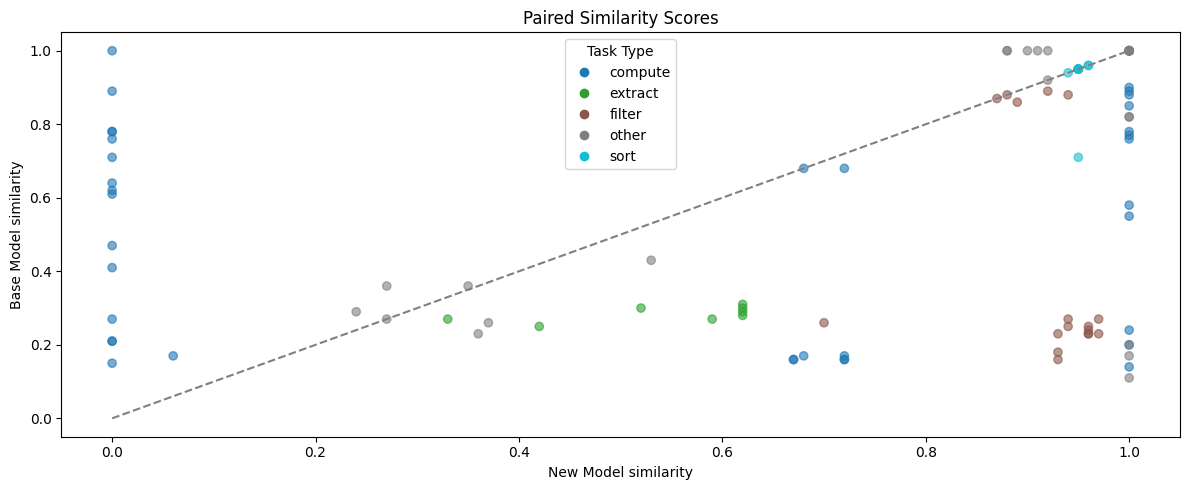

In [42]:
new_model2 = new_model.sort_values('test_case_id').reset_index(drop=True)
base_model2 = base_model.sort_values('test_case_id').reset_index(drop=True)
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=base_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("Base Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()